In [561]:
import pandas as pd
import matplotlib.pyplot as plt

In [562]:
df=pd.read_csv("salary_csv.csv")

In [563]:
df.head()

,YearsExperience,Salary
0,0.8,28500
1,1.0,31000
2,1.2,32500
3,1.4,34800
4,1.5,36000


In [564]:
df.tail()

,YearsExperience,Salary
45,9.4,125500
46,9.6,128000
47,9.8,130500
48,10.0,133000
49,10.5,137500


In [565]:
df.isna().sum()

YearsExperience    0
Salary             0
dtype: int64

In [566]:
df.columns

Index(['YearsExperience', 'Salary'], dtype='str')

In [567]:
x=df[["YearsExperience"]]
y=df["Salary"]

Text(0, 0.5, 'salary')

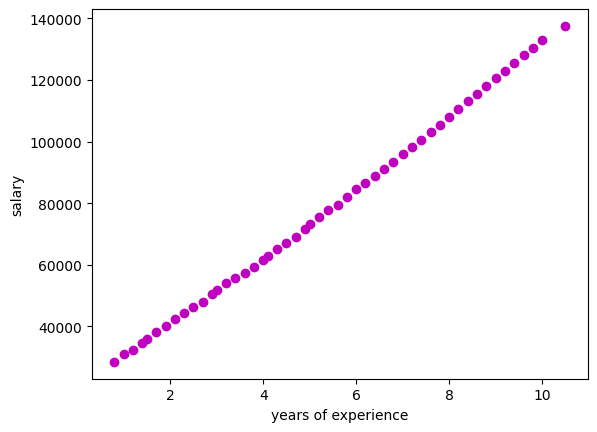

In [568]:
plt.scatter(x,y,color="m")
plt.xlabel("years of experience")
plt.ylabel("salary")

In [569]:
x=df.drop(columns="Salary")
y=df["Salary"]

In [570]:
from sklearn.model_selection import train_test_split

In [571]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.20,random_state=42)

In [572]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[11272.04]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['YearsExperience']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.791e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [573]:
y_pred=model.predict(x_test)
y_pred

array([ 53980.4627344 , 110340.65662549,  90050.9868247 , 123867.10315936,
        62998.09375697, 130630.32642629,  81033.35580212,  78778.94804648,
        94559.80233599,  66379.70539044])

In [574]:
print(y_test)

13     54000
39    110500
30     88900
45    125500
17     61500
48    133000
26     79500
25     77800
32     93500
19     65000
Name: Salary, dtype: int64


In [575]:
model.predict([[9.4]])

c:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([123867.10315936])

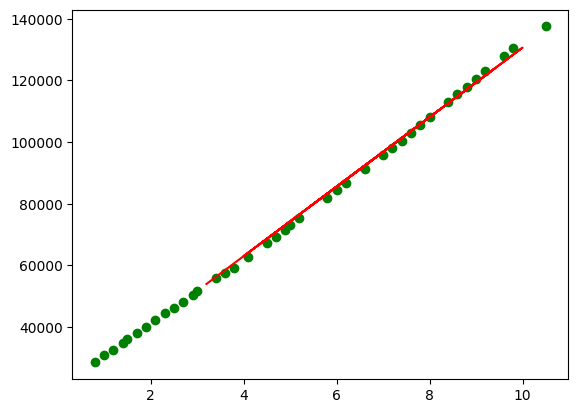

In [576]:
plt.scatter(x_train,y_train,color="g")
plt.plot(x_test,y_pred,color="r")

In [577]:
print(model.coef_)

[11272.03877822]


In [578]:
print(model.intercept_)

17909.938644096655


In [579]:
df1=pd.DataFrame({"actual":y_test,"predicted":y_pred,"error":y_test-y_pred})
df1

,actual,predicted,error
13,54000,53980.462734,19.537266
39,110500,110340.656625,159.343375
30,88900,90050.986825,-1150.986825
45,125500,123867.103159,1632.896841
17,61500,62998.093757,-1498.093757
48,133000,130630.326426,2369.673574
26,79500,81033.355802,-1533.355802
25,77800,78778.948046,-978.948046
32,93500,94559.802336,-1059.802336
19,65000,66379.705390,-1379.705390


In [580]:
from sklearn.metrics import mean_absolute_percentage_error,mean_squared_error,root_mean_squared_error,r2_score

In [581]:
print(mean_absolute_percentage_error(y_pred,y_test))

0.013303231652475628


In [582]:
print(mean_squared_error(y_pred,y_test))

1821281.9778574794


In [583]:
print(root_mean_squared_error(y_pred,y_test))

1349.5488052891897


In [584]:
print(r2_score(y_pred,y_test))

0.9969734254341637
